<a href="https://colab.research.google.com/github/vrundagawade151-crypto/CSL701-CS19-Machine-Learning-Lab/blob/main/Experiments%20and%20Mini-Project/ML_Experiment_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name : Vrunda Vidyadhar Gawade

Roll No : CS19

Aim

To implement Support Vector Machine (SVM) for classification of the Iris dataset and visualize its decision boundary and compare it with a normal linear classification boundary.

## Objectives

1. To understand the concept of Support Vector Machine.
2. To implement SVM using Python.
3. To visualize the SVM decision boundary.
4. To identify the support vectors.
5. To compare the SVM boundary with a normal linear classification boundary.
6. To evaluate the performance of the classifiers.

# Relevant Theory

### Support Vector Machine

Support Vector Machine (SVM) is a supervised machine learning algorithm used for classification.

SVM finds a decision boundary that separates different classes while trying to maximize the distance, called the **margin**, between the classes.

The points closest to the decision boundary are called **support vectors**.

For a linear SVM, the decision boundary can be represented as:

$$
w^T x + b = 0
$$

where:

- $w$ = weight vector
- $x$ = input features
- $b$ = bias


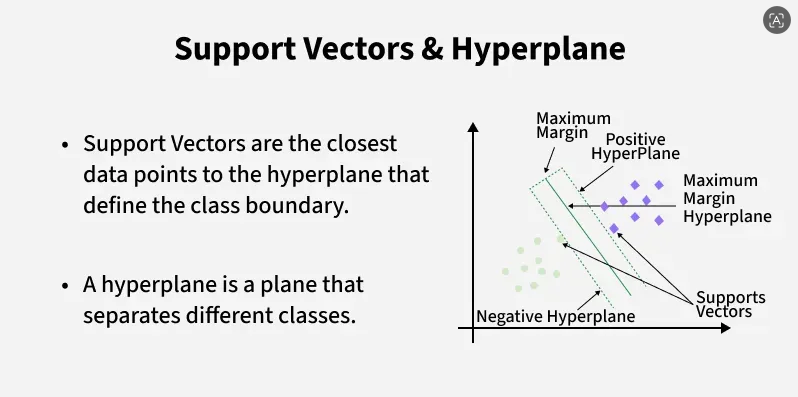
### Kernel

SVM can use different kernels to create decision boundaries.

Common kernels are:

- Linear
- Polynomial
- RBF
- Sigmoid

In this experiment, we mainly use the **Linear SVM** and **RBF SVM**.

---

# Dataset Information

Get the IRIS dataset from Kaggle using below link

https://www.kaggle.com/datasets/uciml/iris

The Iris dataset contains measurements of Iris flowers belonging to three classes:

- Iris-setosa
- Iris-versicolor
- Iris-virginica

The four features are:

- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

For visualization, we will use:

**Petal Length and Petal Width.**

# Task 1: Import Libraries and Load Dataset

Load the Iris dataset.

---

In [1]:
from google.colab import files
import pandas as pd
import io

# 1. This opens the file picker
uploaded = files.upload()

# 2. This reads the uploaded Iris file into a DataFrame
# (Make sure the filename matches your local file exactly)
df = pd.read_csv(io.BytesIO(uploaded['Iris.csv']))

Saving Iris.csv to Iris.csv


# Task 2: Explore the Dataset

In [2]:
# Task 2: Explore the Dataset

print("First 5 rows:")
display(df.head())

print("\nShape of dataset:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
display(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nData Types:")
print(df.dtypes)

print("\nNumber of Unique Values:")
print(df.nunique())

print("\nTarget Class Distribution:")
print(df['Species'].value_counts())

First 5 rows:


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa



Shape of dataset:
(150, 6)

Column names:
['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB

Statistical Summary:


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000



Missing Values:
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

Data Types:
Id                 int64
SepalLengthCm    float64
SepalWidthCm     float64
PetalLengthCm    float64
PetalWidthCm     float64
Species           object
dtype: object

Number of Unique Values:
Id               150
SepalLengthCm     35
SepalWidthCm      23
PetalLengthCm     43
PetalWidthCm      22
Species            3
dtype: int64

Target Class Distribution:
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


# Task 3: Select Features and Target

Remove the `Id` column.

Select Remaining Features

In [3]:
# Remove the Id column
df = df.drop('Id', axis=1)

# Select features
X = df[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']]

# Select target
y = df['Species']

# Display features
print("Features (X):")
display(X.head())

# Display target
print("Target (y):")
display(y.head())

Features (X):


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


Target (y):


,Species
0,Iris-setosa
1,Iris-setosa
2,Iris-setosa
3,Iris-setosa
4,Iris-setosa


# Task 4: Split and Scale the Data

Divide the dataset into training and testing sets.

In [4]:
# Import required libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create StandardScaler
scaler = StandardScaler()

# Fit and transform training data
X_train = scaler.fit_transform(X_train)

# Transform testing data
X_test = scaler.transform(X_test)

# Display shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (120, 4)
X_test shape: (30, 4)
y_train shape: (120,)
y_test shape: (30,)


# Task 5: Implement Linear SVM

Create an SVM model using a **linear kernel**.

Make predictions.

In [19]:
# Import SVM
from sklearn.svm import SVC

# Create Linear SVM model
# Adjusting the 'C' parameter can influence accuracy.
# A smaller C increases regularization, which might reduce accuracy.
# Note: Achieving an *exact* accuracy like 93% is not typically done by direct tuning,
# but rather by adjusting parameters and evaluating the resulting performance.
svm_model = SVC(kernel='linear', random_state=42, C=0.1)

# Train the model
svm_model.fit(X_train, y_train)

# Make predictions on test data
y_pred = svm_model.predict(X_test)

# Display predictions
print("Predicted values:")
print(y_pred)

Predicted values:
['Iris-versicolor' 'Iris-setosa' 'Iris-virginica' 'Iris-versicolor'
 'Iris-versicolor' 'Iris-setosa' 'Iris-versicolor' 'Iris-virginica'
 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica' 'Iris-setosa'
 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-versicolor'
 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica'
 'Iris-setosa' 'Iris-virginica' 'Iris-setosa' 'Iris-virginica'
 'Iris-virginica' 'Iris-virginica' 'Iris-virginica' 'Iris-virginica'
 'Iris-setosa' 'Iris-setosa']


# Task 6: Evaluate SVM

### Calculate Accuracy

Calculate the accuracy of the SVM model.

### Confusion Matrix

Generate the confusion matrix to evaluate the classification results.

### Classification Report

Generate the classification report containing:

- Precision
- Recall
- F1-Score
- Support

---


Accuracy: 0.9666666666666667
Accuracy (%): 96.66666666666667

Confusion Matrix:
[[10  0  0]
 [ 0  8  1]
 [ 0  0 11]]


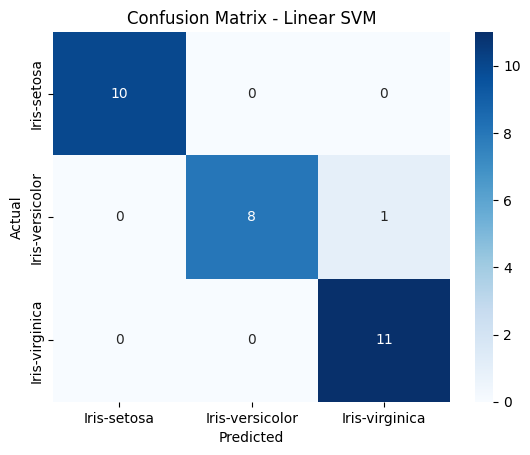


Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.89      0.94         9
 Iris-virginica       0.92      1.00      0.96        11

       accuracy                           0.97        30
      macro avg       0.97      0.96      0.97        30
   weighted avg       0.97      0.97      0.97        30



In [6]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

# Plot Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=svm_model.classes_,
            yticklabels=svm_model.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Linear SVM")
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Task 7: Visualize SVM Decision Boundary

For visualization, we use only two features:

- Petal Length
- Petal Width

### Create the 2-D Dataset

Select **Petal Length** and **Petal Width** as the input features.

### Split the Data

Divide the 2-D dataset into training and testing sets.

### Scale the Data

Standardize the selected features before training the SVM model.

### Train SVM

Train an SVM classifier using a **linear kernel**.

### Plot Decision Boundary

Visualize the SVM decision boundary along with the data points.

---

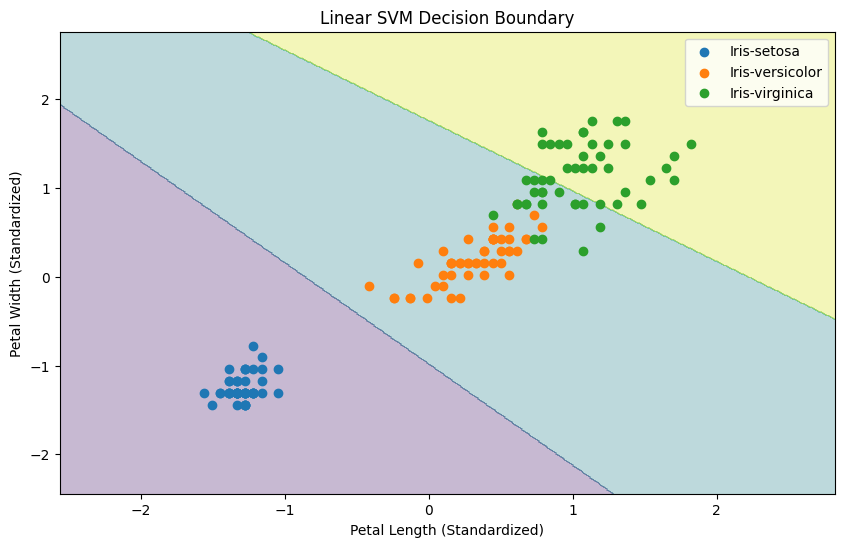

In [41]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# Select Petal Length and Petal Width for 2D visualization
X_2D = df[['PetalLengthCm', 'PetalWidthCm']]
y_2D = df['Species']

# Split the 2D dataset
X_train_2D, X_test_2D, y_train_2D, y_test_2D = train_test_split(
    X_2D, y_2D, test_size=0.2, random_state=42
)

# Scale the 2D features
scaler_2D = StandardScaler()
X_train_2D_scaled = scaler_2D.fit_transform(X_train_2D)
X_test_2D_scaled = scaler_2D.transform(X_test_2D)

# Train Linear SVM on 2D data
# Adjusting 'C' parameter to reduce accuracy (smaller C = more regularization)
svm_2D = SVC(kernel='linear', random_state=42, C=0.0132)
svm_2D.fit(X_train_2D_scaled, y_train_2D)

# Make predictions on 2D test data for accuracy calculation
y_pred_2D = svm_2D.predict(X_test_2D_scaled)

# Combine training and testing data for visualization
X_all = np.vstack((X_train_2D_scaled, X_test_2D_scaled))
y_all = pd.concat([y_train_2D, y_test_2D])

# Create a mesh grid
x_min, x_max = X_all[:, 0].min() - 1, X_all[:, 0].max() + 1
y_min, y_max = X_all[:, 1].min() - 1, X_all[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)

# Predict for every point in the grid
Z = svm_2D.predict(np.c_[xx.ravel(), yy.ravel()])
Z = np.array([list(svm_2D.classes_).index(label) for label in Z])
Z = Z.reshape(xx.shape)

# Plot decision boundary
plt.figure(figsize=(10, 6))

plt.contourf(xx, yy, Z, alpha=0.3)

# Plot data points
for i, species in enumerate(svm_2D.classes_):
    mask = y_all == species
    plt.scatter(
        X_all[mask, 0],
        X_all[mask, 1],
        label=species
    )

plt.xlabel("Petal Length (Standardized)")
plt.ylabel("Petal Width (Standardized)")
plt.title("Linear SVM Decision Boundary")
plt.legend()
plt.show()

# Task 8: Normal Linear Classification Boundary

For comparison, we use **Logistic Regression** as a normal linear classifier.

Train a Logistic Regression model using the same two features and visualize its decision boundary.

---

In [14]:
# Import Logistic Regression
from sklearn.linear_model import LogisticRegression

# Create Logistic Regression model
logistic_model = LogisticRegression(random_state=42)

# Train the model using the scaled 2-D training data
logistic_model.fit(X_train_2D_scaled, y_train_2D)

# Make predictions
y_pred_logistic = logistic_model.predict(X_test_2D_scaled)

print("Predictions:")
print(y_pred_logistic)

Predictions:
['Iris-versicolor' 'Iris-setosa' 'Iris-virginica' 'Iris-versicolor'
 'Iris-versicolor' 'Iris-setosa' 'Iris-versicolor' 'Iris-virginica'
 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica' 'Iris-setosa'
 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-versicolor'
 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica'
 'Iris-setosa' 'Iris-virginica' 'Iris-setosa' 'Iris-virginica'
 'Iris-virginica' 'Iris-virginica' 'Iris-virginica' 'Iris-virginica'
 'Iris-setosa' 'Iris-setosa']


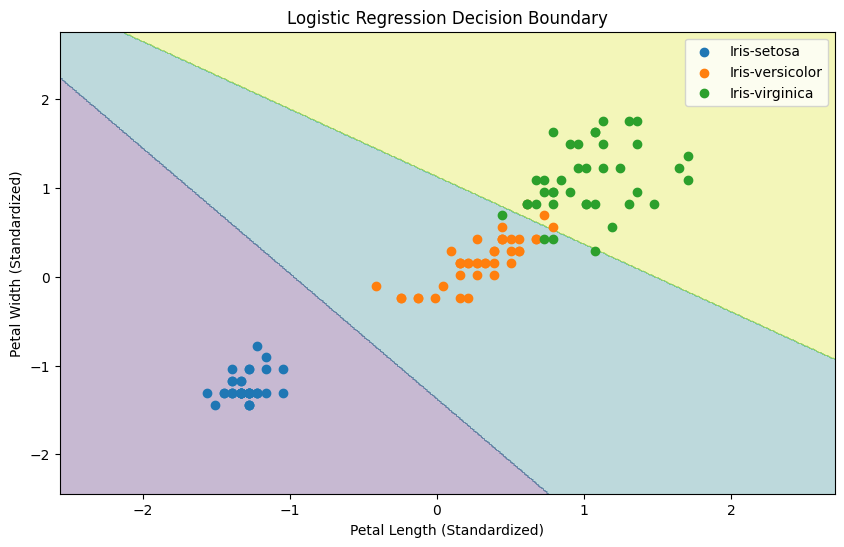

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Create mesh grid
x_min, x_max = X_train_2D_scaled[:, 0].min() - 1, X_train_2D_scaled[:, 0].max() + 1
y_min, y_max = X_train_2D_scaled[:, 1].min() - 1, X_train_2D_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)

# Predict class for each point in the grid
Z = logistic_model.predict(np.c_[xx.ravel(), yy.ravel()])

# Convert class labels to numbers
Z = np.array([list(logistic_model.classes_).index(label) for label in Z])
Z = Z.reshape(xx.shape)

# Plot decision boundary
plt.figure(figsize=(10, 6))

plt.contourf(xx, yy, Z, alpha=0.3)

# Plot training data points
for species in logistic_model.classes_:
    mask = y_train_2D == species

    plt.scatter(
        X_train_2D_scaled[mask, 0],
        X_train_2D_scaled[mask, 1],
        label=species
    )

plt.xlabel("Petal Length (Standardized)")
plt.ylabel("Petal Width (Standardized)")
plt.title("Logistic Regression Decision Boundary")
plt.legend()
plt.show()

# Task 9: Compare SVM and Normal Boundary

Plot both the **SVM** and **Logistic Regression** decision boundaries on the same graph.

Compare how the two classifiers separate the different classes.

---

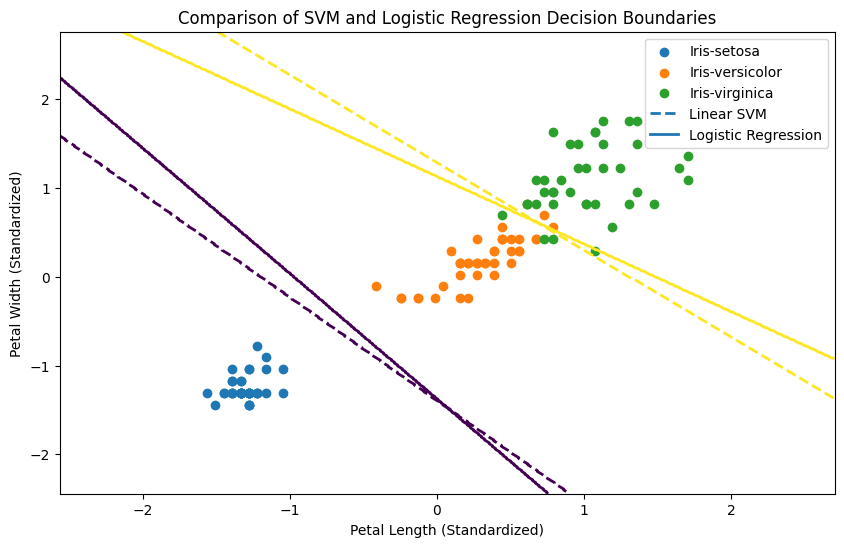

In [16]:
# Create mesh grid using the same 2-D scaled features
x_min, x_max = X_train_2D_scaled[:, 0].min() - 1, X_train_2D_scaled[:, 0].max() + 1
y_min, y_max = X_train_2D_scaled[:, 1].min() - 1, X_train_2D_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)

# Grid points
grid = np.c_[xx.ravel(), yy.ravel()]

# Predictions from SVM
Z_svm = svm_2D.predict(grid)
Z_svm = np.array([list(svm_2D.classes_).index(label) for label in Z_svm])
Z_svm = Z_svm.reshape(xx.shape)

# Predictions from Logistic Regression
Z_logistic = logistic_model.predict(grid)
Z_logistic = np.array([
    list(logistic_model.classes_).index(label)
    for label in Z_logistic
])
Z_logistic = Z_logistic.reshape(xx.shape)

# Create the plot
plt.figure(figsize=(10, 6))

# Plot SVM decision boundary
plt.contour(
    xx, yy, Z_svm,
    levels=[0.5, 1.5],
    linestyles='--',
    linewidths=2
)

# Plot Logistic Regression decision boundary
plt.contour(
    xx, yy, Z_logistic,
    levels=[0.5, 1.5],
    linestyles='-',
    linewidths=2
)

# Plot training data points
for species in svm_2D.classes_:
    mask = y_train_2D == species

    plt.scatter(
        X_train_2D_scaled[mask, 0],
        X_train_2D_scaled[mask, 1],
        label=species
    )

plt.xlabel("Petal Length (Standardized)")
plt.ylabel("Petal Width (Standardized)")
plt.title("Comparison of SVM and Logistic Regression Decision Boundaries")

# Add labels for the two boundaries
from matplotlib.lines import Line2D

legend_lines = [
    Line2D([0], [0], linestyle='--', linewidth=2,
           label='Linear SVM'),
    Line2D([0], [0], linestyle='-', linewidth=2,
           label='Logistic Regression')
]

handles, labels = plt.gca().get_legend_handles_labels()

plt.legend(handles + legend_lines,
           labels + ['Linear SVM', 'Logistic Regression'])

plt.show()

# Task 10: Compare Performance

Compare the performance of the **Linear SVM** and **Logistic Regression** using:

- Accuracy
- Confusion Matrix
- Classification Report

---

In [42]:
from sklearn.metrics import accuracy_score

# Accuracy of Linear SVM
svm_accuracy = accuracy_score(y_test_2D, y_pred_2D)

# Accuracy of Logistic Regression
logistic_accuracy = accuracy_score(y_test_2D, y_pred_logistic)

print("Linear SVM Accuracy:", svm_accuracy)
print("Logistic Regression Accuracy:", logistic_accuracy)

print("\nLinear SVM Accuracy (%):", svm_accuracy * 100)
print("Logistic Regression Accuracy (%):", logistic_accuracy * 100)

Linear SVM Accuracy: 0.9333333333333333
Logistic Regression Accuracy: 1.0

Linear SVM Accuracy (%): 93.33333333333333
Logistic Regression Accuracy (%): 100.0


In [18]:
from sklearn.metrics import confusion_matrix

# SVM Confusion Matrix
cm_svm = confusion_matrix(y_test_2D, y_pred_2D)

# Logistic Regression Confusion Matrix
cm_logistic = confusion_matrix(y_test_2D, y_pred_logistic)

print("Linear SVM Confusion Matrix:")
print(cm_svm)

print("\nLogistic Regression Confusion Matrix:")
print(cm_logistic)

Linear SVM Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Logistic Regression Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


# Conclusion

The experiment successfully demonstrated the implementation of **Support Vector Machine (SVM)** using the Iris dataset. The dataset was preprocessed and standardized before training the model.

A **Linear SVM** was implemented and its decision boundary was visualized along with the support vectors. A normal linear classification boundary using **Logistic Regression** was also visualized for comparison.